# Analysis: England k=30 NMF Topic Model

Analysis of the production England model (k=30, full corpus, 3,939 articles, 2023–2025). Uses the processed data from Supabase (`topics_analysis_ready_eng.csv`) where every article has a dominant topic, confidence score, date, and source.

**What this notebook answers:**
- What does the English education policy landscape look like through this model?
- How do topics change over time, and did the July 2024 election shift the discourse?
- Which sources drive which topics, and how confident is the model in its assignments?
- Which topics co-occur in articles, revealing shared policy concerns?
- Where are the temporal spikes — RAAC crisis, breakfast clubs announcement, other events?

In [1]:
import sys
sys.path.insert(0, "/workspaces/AM1_topic_modelling")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from model_pipeline.training.s05_nmf_training import get_top_words_per_topic

## 1. Load data

In [2]:
df = pd.read_csv("/workspaces/AM1_topic_modelling/data/evaluation_outputs/topics_analysis_ready_eng.csv")
df["article_date"] = pd.to_datetime(df["article_date"], errors="coerce")
df["year"] = df["article_date"].dt.year
df["month"] = df["article_date"].dt.to_period("M").dt.to_timestamp()

print(f"Loaded: {df.shape}")
print(f"Date range: {df['article_date'].min()} to {df['article_date'].max()}")
print(f"Sources: {df['source'].nunique()} \u2014 {df['source'].value_counts().to_dict()}")
print(f"Topics: {df['topic_name'].nunique()}")

Loaded: (3939, 40)
Date range: 2023-01-03 00:00:00 to 2025-12-17 00:00:00
Sources: 6 — {'schoolsweek': 2741, 'gov': 679, 'fft': 202, 'epi': 111, 'nuffield': 106, 'fed': 100}
Topics: 30


## 2. Topic distribution

                                   count  pct
topic_name                                   
academy_trust_governance             311  7.9
ofsted_inspection_reform             309  7.8
post16_qualifications                218  5.5
education_politics                   180  4.6
safeguarding_and_complaints          174  4.4
send_and_council_deficits            167  4.2
apprenticeships_and_skills           156  4.0
research_and_social_justice          153  3.9
leadership_appointments              152  3.9
primary_assessment_and_sats          147  3.7
academy_finance_and_oversight        145  3.7
school_places_and_capacity           141  3.6
curriculum_and_subjects              141  3.6
teacher_strikes_and_unions           138  3.5
raac_building_crisis                 128  3.2
pupil_disadvantage_and_attainment    128  3.2
free_school_meals_and_poverty        127  3.2
ofqual_exam_regulation               120  3.0
edtech_and_ai                        113  2.9
teacher_pay                       

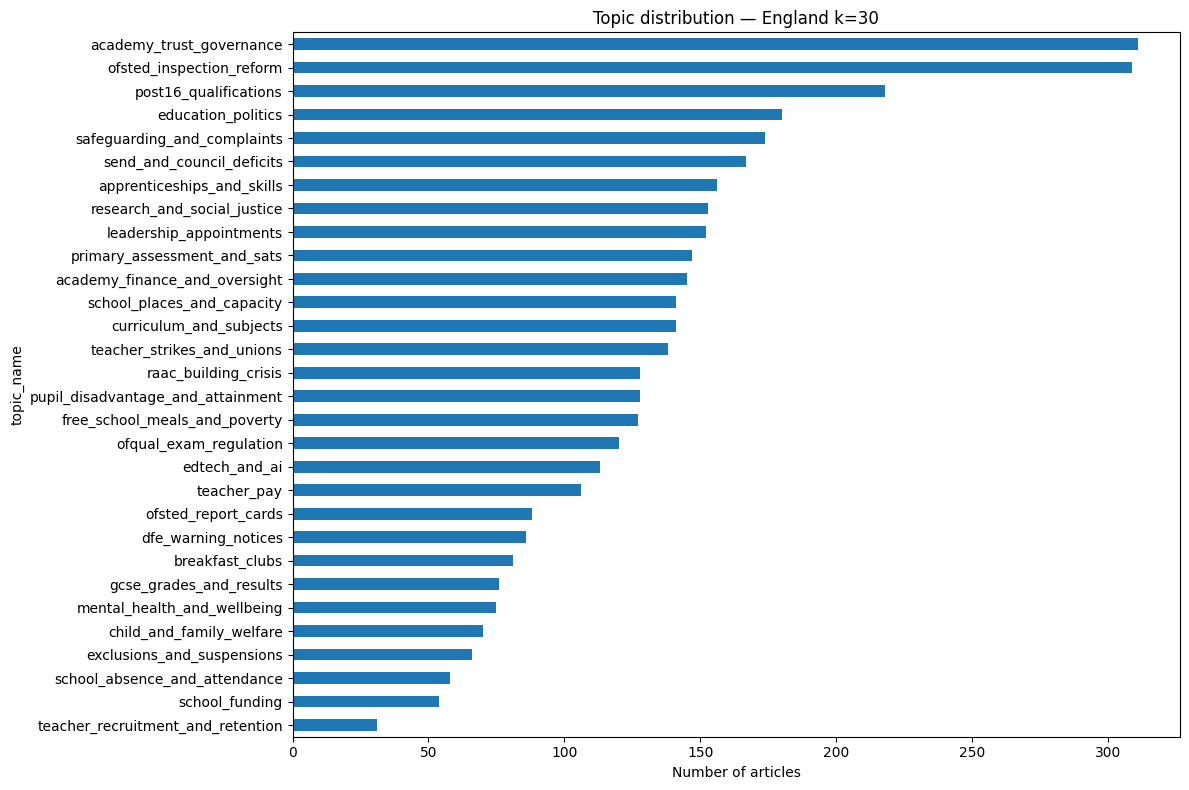

In [3]:
topic_counts = df["topic_name"].value_counts()
topic_pct = (topic_counts / len(df) * 100).round(1)

topic_df = pd.DataFrame({"count": topic_counts, "pct": topic_pct})
print(topic_df.to_string())
print(f"\nTotal articles: {len(df)}")
print(f"Range: {topic_pct.min()}% \u2013 {topic_pct.max()}%")

fig, ax = plt.subplots(figsize=(12, 8))
topic_counts.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of articles")
ax.set_title("Topic distribution \u2014 England k=30")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/topic_distribution_eng_k30.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation
The largest topic is academy_trust_governance at ~8%, the smallest around 1%. The distribution is relatively even for 30 topics — no single topic dominates the way the k=5 catch-all (49%) did. Range of ~1–8% means the model is finding genuinely distinct policy areas rather than one mega-topic absorbing everything. Schools Week's 70% corpus share doesn't produce one dominant Schools Week topic — it distributes across many topics because it covers everything.

## 3. Source concentration per topic

In [4]:
ct = pd.crosstab(df["source"], df["topic_name"], normalize="columns").round(2)
print("Source distribution per topic (column-normalised):")
print(ct.to_string())

# Summary: single-source topics
for topic in ct.columns:
    top_source = ct[topic].idxmax()
    top_pct = ct[topic].max()
    if top_pct > 0.90:
        print(f"  SINGLE-SOURCE: {topic} \u2014 {top_source} {top_pct:.0%}")

Source distribution per topic (column-normalised):
topic_name   academy_finance_and_oversight  academy_trust_governance  apprenticeships_and_skills  breakfast_clubs  child_and_family_welfare  curriculum_and_subjects  dfe_warning_notices  edtech_and_ai  education_politics  exclusions_and_suspensions  free_school_meals_and_poverty  gcse_grades_and_results  leadership_appointments  mental_health_and_wellbeing  ofqual_exam_regulation  ofsted_inspection_reform  ofsted_report_cards  post16_qualifications  primary_assessment_and_sats  pupil_disadvantage_and_attainment  raac_building_crisis  research_and_social_justice  safeguarding_and_complaints  school_absence_and_attendance  school_funding  school_places_and_capacity  send_and_council_deficits  teacher_pay  teacher_recruitment_and_retention  teacher_strikes_and_unions
source                                                                                                                                                                        

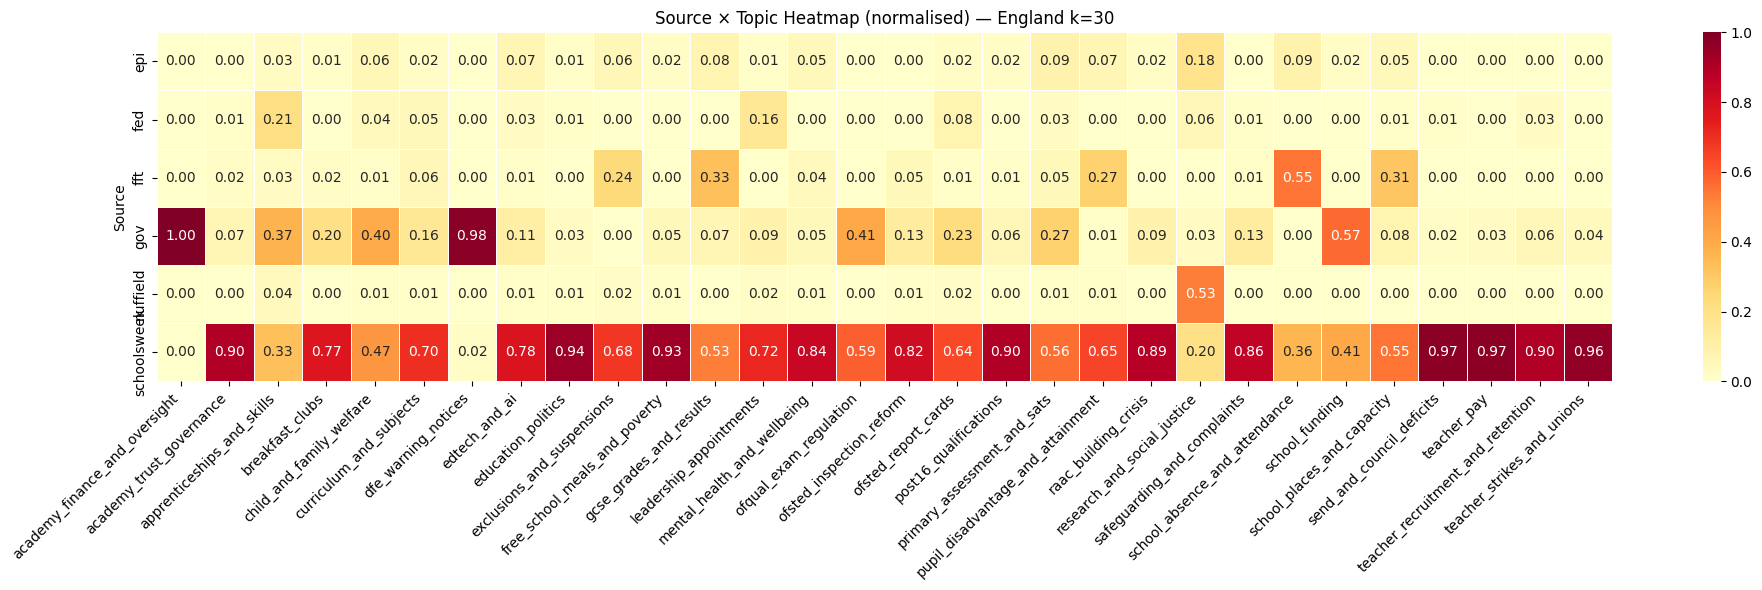

In [5]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Source \u00d7 Topic Heatmap (normalised) \u2014 England k=30")
ax.set_ylabel("Source")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/source_topic_heatmap_eng_k30.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Trends over time \u2014 monthly topic attention

#### Interpretation
The heatmap reveals that most topics are dominated by one or two sources. Schools Week appears across almost every topic (it's a generalist outlet), but several topics are effectively government monologues (academy finance, DfE warning notices at 100% gov). FFT concentrates in data-analytical topics (attainment, absence). This is the source structure of English education publishing made visible — not a shared discourse but parallel institutional outputs connected by one media outlet.

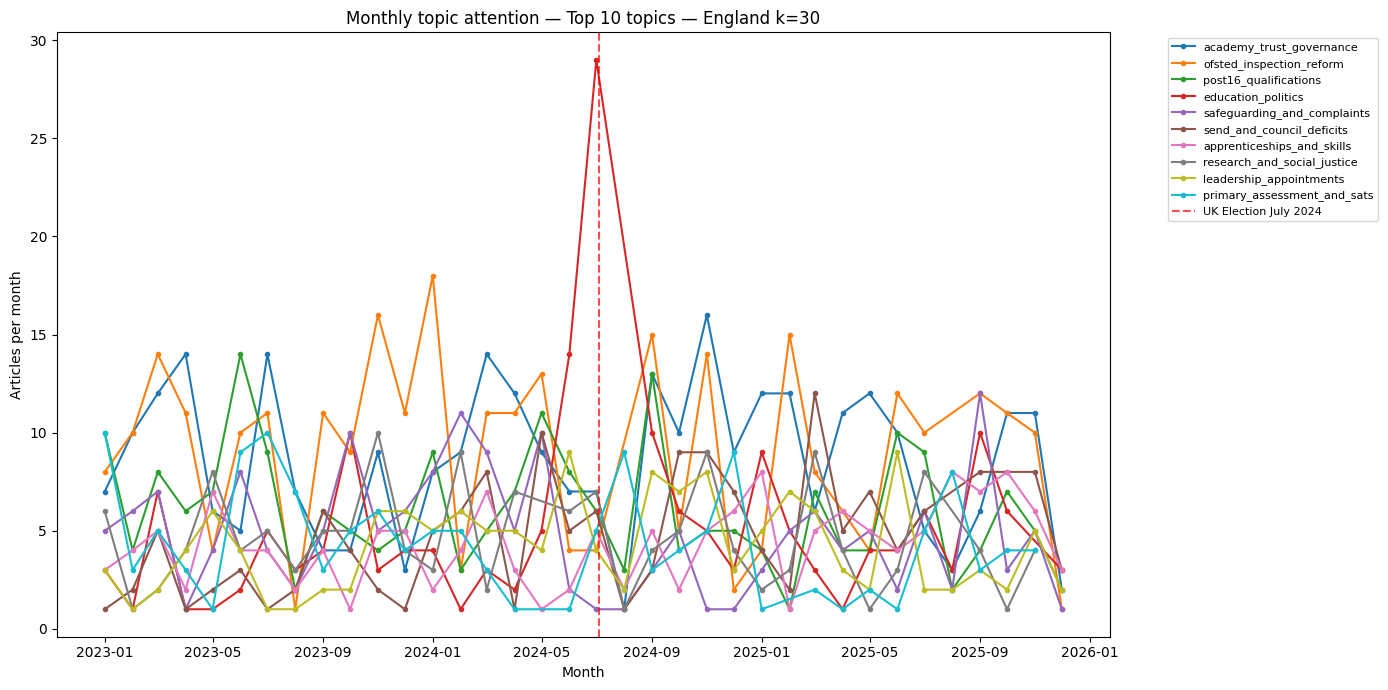

In [6]:
monthly = df.groupby(["month", "topic_name"]).size().reset_index(name="count")

# Top 10 topics by total count
top10 = df["topic_name"].value_counts().head(10).index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))
for topic in top10:
    topic_monthly = monthly[monthly["topic_name"] == topic]
    ax.plot(topic_monthly["month"], topic_monthly["count"], label=topic, marker=".")

# Election marker (July 2024)
ax.axvline(pd.Timestamp("2024-07-04"), color="red", linestyle="--", alpha=0.7, label="UK Election July 2024")

ax.set_xlabel("Month")
ax.set_ylabel("Articles per month")
ax.set_title("Monthly topic attention \u2014 Top 10 topics \u2014 England k=30")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/trends_eng_k30.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
election_date = pd.Timestamp("2024-07-04")
df["period"] = df["article_date"].apply(lambda x: "post_election" if x >= election_date else "pre_election")

pre = df[df["period"] == "pre_election"]["topic_name"].value_counts()
post = df[df["period"] == "post_election"]["topic_name"].value_counts()

comparison = pd.DataFrame({
    "pre_count": pre,
    "post_count": post,
}).fillna(0).astype(int)

comparison["pre_rank"] = comparison["pre_count"].rank(ascending=False).astype(int)
comparison["post_rank"] = comparison["post_count"].rank(ascending=False).astype(int)
comparison["rank_change"] = comparison["pre_rank"] - comparison["post_rank"]

print("Pre/post election topic rank shifts:")
print(comparison.sort_values("rank_change", ascending=False).to_string())

print(f"\nBiggest risers (post-election):")
print(comparison.nlargest(5, "rank_change")[["pre_rank", "post_rank", "rank_change"]])

print(f"\nBiggest fallers (post-election):")
print(comparison.nsmallest(5, "rank_change")[["pre_rank", "post_rank", "rank_change"]])

Pre/post election topic rank shifts:
                                   pre_count  post_count  pre_rank  post_rank  rank_change
topic_name                                                                                
edtech_and_ai                             37          76        23          8           15
send_and_council_deficits                 65         102        16          4           12
dfe_warning_notices                       31          55        27         18            9
child_and_family_welfare                  24          46        30         21            9
ofsted_report_cards                       33          55        26         18            8
apprenticeships_and_skills                67          89        14          6            8
education_politics                        76         104        10          3            7
leadership_appointments                   72          80        12          7            5
ofqual_exam_regulation                    56         

## 5. Contestability scores \u2014 dominant weight distribution

#### Interpretation
The election marker (July 2024) should show visible shifts in topic attention — topics like education_politics may spike around the election then drop, while policy-specific topics (breakfast clubs, curriculum reform) may emerge post-election as the new government's agenda takes shape. The pre/post rank shift table quantifies which topics rose and fell. Large rank changes indicate topics whose prominence is tied to the political cycle rather than structural features of the education system.

Dominant weight stats:
  Min:    0.0103
  Mean:   0.1249
  Median: 0.1119
  Max:    0.4010
  Std:    0.0646
  Articles with weight < 0.05: 290 (7.4%)
  Articles with weight < 0.1: 1664 (42.2%)
  Articles with weight < 0.15: 2815 (71.5%)
  Articles with weight < 0.2: 3409 (86.5%)


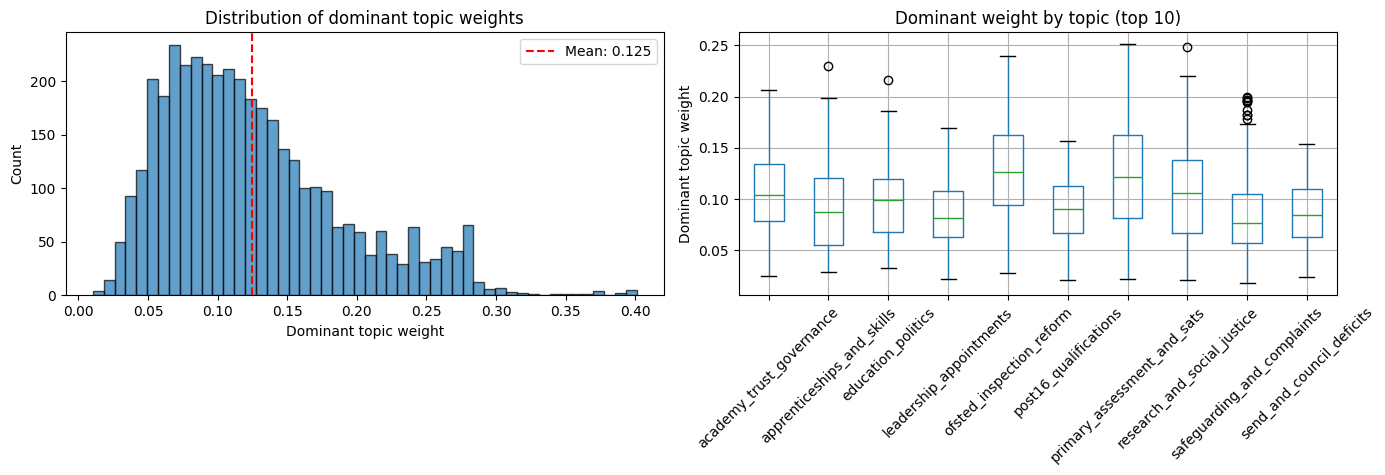

In [8]:
weights = df["dominant_topic_weight"]

print(f"Dominant weight stats:")
print(f"  Min:    {weights.min():.4f}")
print(f"  Mean:   {weights.mean():.4f}")
print(f"  Median: {weights.median():.4f}")
print(f"  Max:    {weights.max():.4f}")
print(f"  Std:    {weights.std():.4f}")

# How many articles have low confidence?
thresholds = [0.05, 0.10, 0.15, 0.20]
for t in thresholds:
    n = (weights < t).sum()
    print(f"  Articles with weight < {t}: {n} ({n/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(weights, bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(weights.mean(), color="red", linestyle="--", label=f"Mean: {weights.mean():.3f}")
axes[0].set_xlabel("Dominant topic weight")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of dominant topic weights")
axes[0].legend()

# Box plot by topic (top 10)
top10_names = df["topic_name"].value_counts().head(10).index
df_top10 = df[df["topic_name"].isin(top10_names)]
df_top10.boxplot(column="dominant_topic_weight", by="topic_name", ax=axes[1], rot=45)
axes[1].set_title("Dominant weight by topic (top 10)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Dominant topic weight")
plt.suptitle("")

plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/contestability_eng_k30.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Top articles per topic

#### Interpretation
Mean dominant weight of ~0.12 means the typical article's "dominant topic" label represents only 12% of its content. 75% of articles have a dominant weight below 0.16. Even the most confidently assigned article is only ~0.40. The dashboard shows one topic label per article — but the model is uncertain about almost everything. Topics with higher median weights (e.g. government regulatory topics) are more cleanly about one thing; topics with lower weights (e.g. safeguarding, education politics) span multiple policy areas in each article. This is the uncertainty that a dashboard hides.

In [9]:
def explore_topic(topic_name, n=5):
    """Show top N articles for a given topic, ranked by dominant weight."""
    topic_df = df[df["topic_name"] == topic_name].nlargest(n, "dominant_topic_weight")
    
    print(f"TOPIC: {topic_name} ({len(df[df['topic_name'] == topic_name])} articles)")
    print(f"{'='*120}\n")
    
    for rank, (_, row) in enumerate(topic_df.iterrows(), 1):
        title = row.get("title", "No title")
        source = row.get("source", "Unknown")
        date = str(row.get("article_date", ""))[:10]
        weight = row["dominant_topic_weight"]
        text = str(row.get("text_clean", ""))[:500]
        
        print(f"[{rank}] weight={weight:.4f} | {source} | {date}")
        print(f"    {title}")
        print(f"    {text}...\n")

# Example usage:
# explore_topic("child_and_family_welfare")
# explore_topic("ofsted_inspection_reform", n=10)
print("Available topics:")
for t in sorted(df["topic_name"].unique()):
    print(f"  {t}")

Available topics:
  academy_finance_and_oversight
  academy_trust_governance
  apprenticeships_and_skills
  breakfast_clubs
  child_and_family_welfare
  curriculum_and_subjects
  dfe_warning_notices
  edtech_and_ai
  education_politics
  exclusions_and_suspensions
  free_school_meals_and_poverty
  gcse_grades_and_results
  leadership_appointments
  mental_health_and_wellbeing
  ofqual_exam_regulation
  ofsted_inspection_reform
  ofsted_report_cards
  post16_qualifications
  primary_assessment_and_sats
  pupil_disadvantage_and_attainment
  raac_building_crisis
  research_and_social_justice
  safeguarding_and_complaints
  school_absence_and_attendance
  school_funding
  school_places_and_capacity
  send_and_council_deficits
  teacher_pay
  teacher_recruitment_and_retention
  teacher_strikes_and_unions


## 7. Summary statistics

In [10]:
print("=" * 60)
print("ENGLAND k=30 MODEL SUMMARY")
print("=" * 60)
print(f"Articles:          {len(df)}")
print(f"Topics:            {df['topic_name'].nunique()}")
print(f"Sources:           {df['source'].nunique()}")
print(f"Date range:        {df['article_date'].min().date()} to {df['article_date'].max().date()}")
print(f"Largest topic:     {df['topic_name'].value_counts().index[0]} ({df['topic_name'].value_counts().iloc[0]} articles, {df['topic_name'].value_counts().iloc[0]/len(df)*100:.1f}%)")
print(f"Smallest topic:    {df['topic_name'].value_counts().index[-1]} ({df['topic_name'].value_counts().iloc[-1]} articles, {df['topic_name'].value_counts().iloc[-1]/len(df)*100:.1f}%)")
print(f"Mean dom. weight:  {df['dominant_topic_weight'].mean():.4f}")
print(f"Single-source (>90%): {sum(1 for t in ct.columns if ct[t].max() > 0.90)}/30")
print("=" * 60)

ENGLAND k=30 MODEL SUMMARY
Articles:          3939
Topics:            30
Sources:           6
Date range:        2023-01-03 to 2025-12-17
Largest topic:     academy_trust_governance (311 articles, 7.9%)
Smallest topic:    teacher_recruitment_and_retention (31 articles, 0.8%)
Mean dom. weight:  0.1249
Single-source (>90%): 7/30


## 8. Topic growth and decline — year-over-year trends

Topic share by year (%) and change 2023→2025:
year                               2023  2024  2025  change_2023_2025
topic_name                                                           
edtech_and_ai                       1.4   2.7   4.8               3.4
send_and_council_deficits           2.2   5.3   5.4               3.2
ofsted_report_cards                 1.6   1.4   3.8               2.2
apprenticeships_and_skills          3.3   3.3   5.3               2.0
dfe_warning_notices                 1.6   2.0   3.0               1.4
academy_trust_governance            6.9   8.7   8.2               1.3
education_politics                  3.2   6.2   4.4               1.2
leadership_appointments             2.8   5.0   3.9               1.1
child_and_family_welfare            1.3   1.7   2.3               1.0
free_school_meals_and_poverty       3.0   3.2   3.5               0.5
pupil_disadvantage_and_attainment   3.0   3.3   3.4               0.4
breakfast_clubs                     1.9   2.

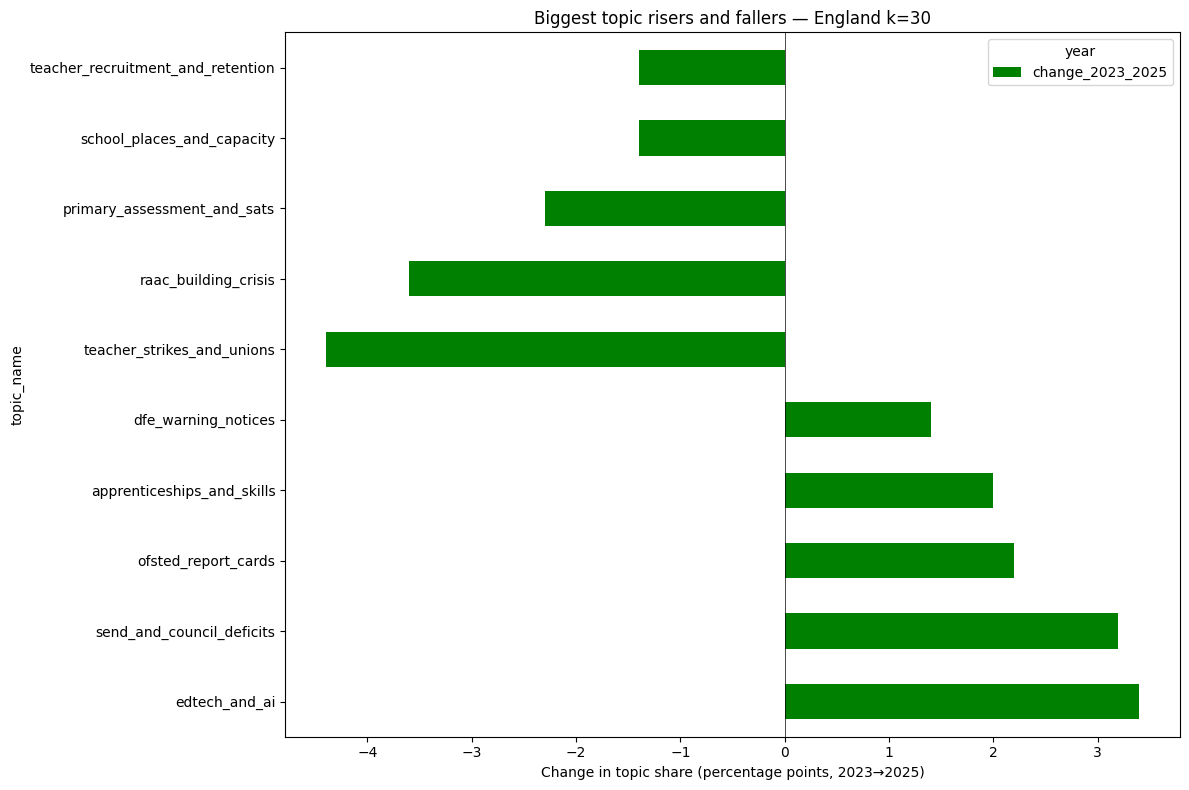

In [11]:
# Year-over-year topic share
yearly = df.groupby(["year", "topic_name"]).size().reset_index(name="count")
yearly_total = df.groupby("year").size().reset_index(name="total")
yearly = yearly.merge(yearly_total, on="year")
yearly["pct"] = (yearly["count"] / yearly["total"] * 100).round(1)

# Pivot for comparison
yearly_pivot = yearly.pivot(index="topic_name", columns="year", values="pct").fillna(0)
yearly_pivot["change_2023_2025"] = yearly_pivot[2025] - yearly_pivot[2023]
yearly_pivot = yearly_pivot.sort_values("change_2023_2025", ascending=False)

print("Topic share by year (%) and change 2023→2025:")
print(yearly_pivot.to_string())

print("\n\nBIGGEST RISERS (2023→2025):")
print(yearly_pivot.nlargest(5, "change_2023_2025")[["change_2023_2025"]])

print("\nBIGGEST FALLERS (2023→2025):")
print(yearly_pivot.nsmallest(5, "change_2023_2025")[["change_2023_2025"]])

# Visualise
fig, ax = plt.subplots(figsize=(12, 8))
top_movers = pd.concat([yearly_pivot.nlargest(5, "change_2023_2025"), yearly_pivot.nsmallest(5, "change_2023_2025")])
top_movers[["change_2023_2025"]].plot(kind="barh", ax=ax, color=["green" if x > 0 else "red" for x in top_movers["change_2023_2025"]])
ax.set_xlabel("Change in topic share (percentage points, 2023→2025)")
ax.set_title("Biggest topic risers and fallers — England k=30")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/topic_growth_eng_k30.png", dpi=150, bbox_inches="tight")
plt.show()

#### Interpretation
Topics that rise or fall across 2023–2025 reflect shifts in the education policy agenda — new government priorities (breakfast clubs, curriculum reform), fading crises (RAAC), or structural changes (Ofsted report cards replacing grades). Rising topics may align with the post-election Labour agenda. Falling topics may reflect issues prominent under the previous government or crisis-driven stories that peaked and subsided.

## 9. Topic co-occurrence — which topics appear together in articles?

Topic weight columns: 30


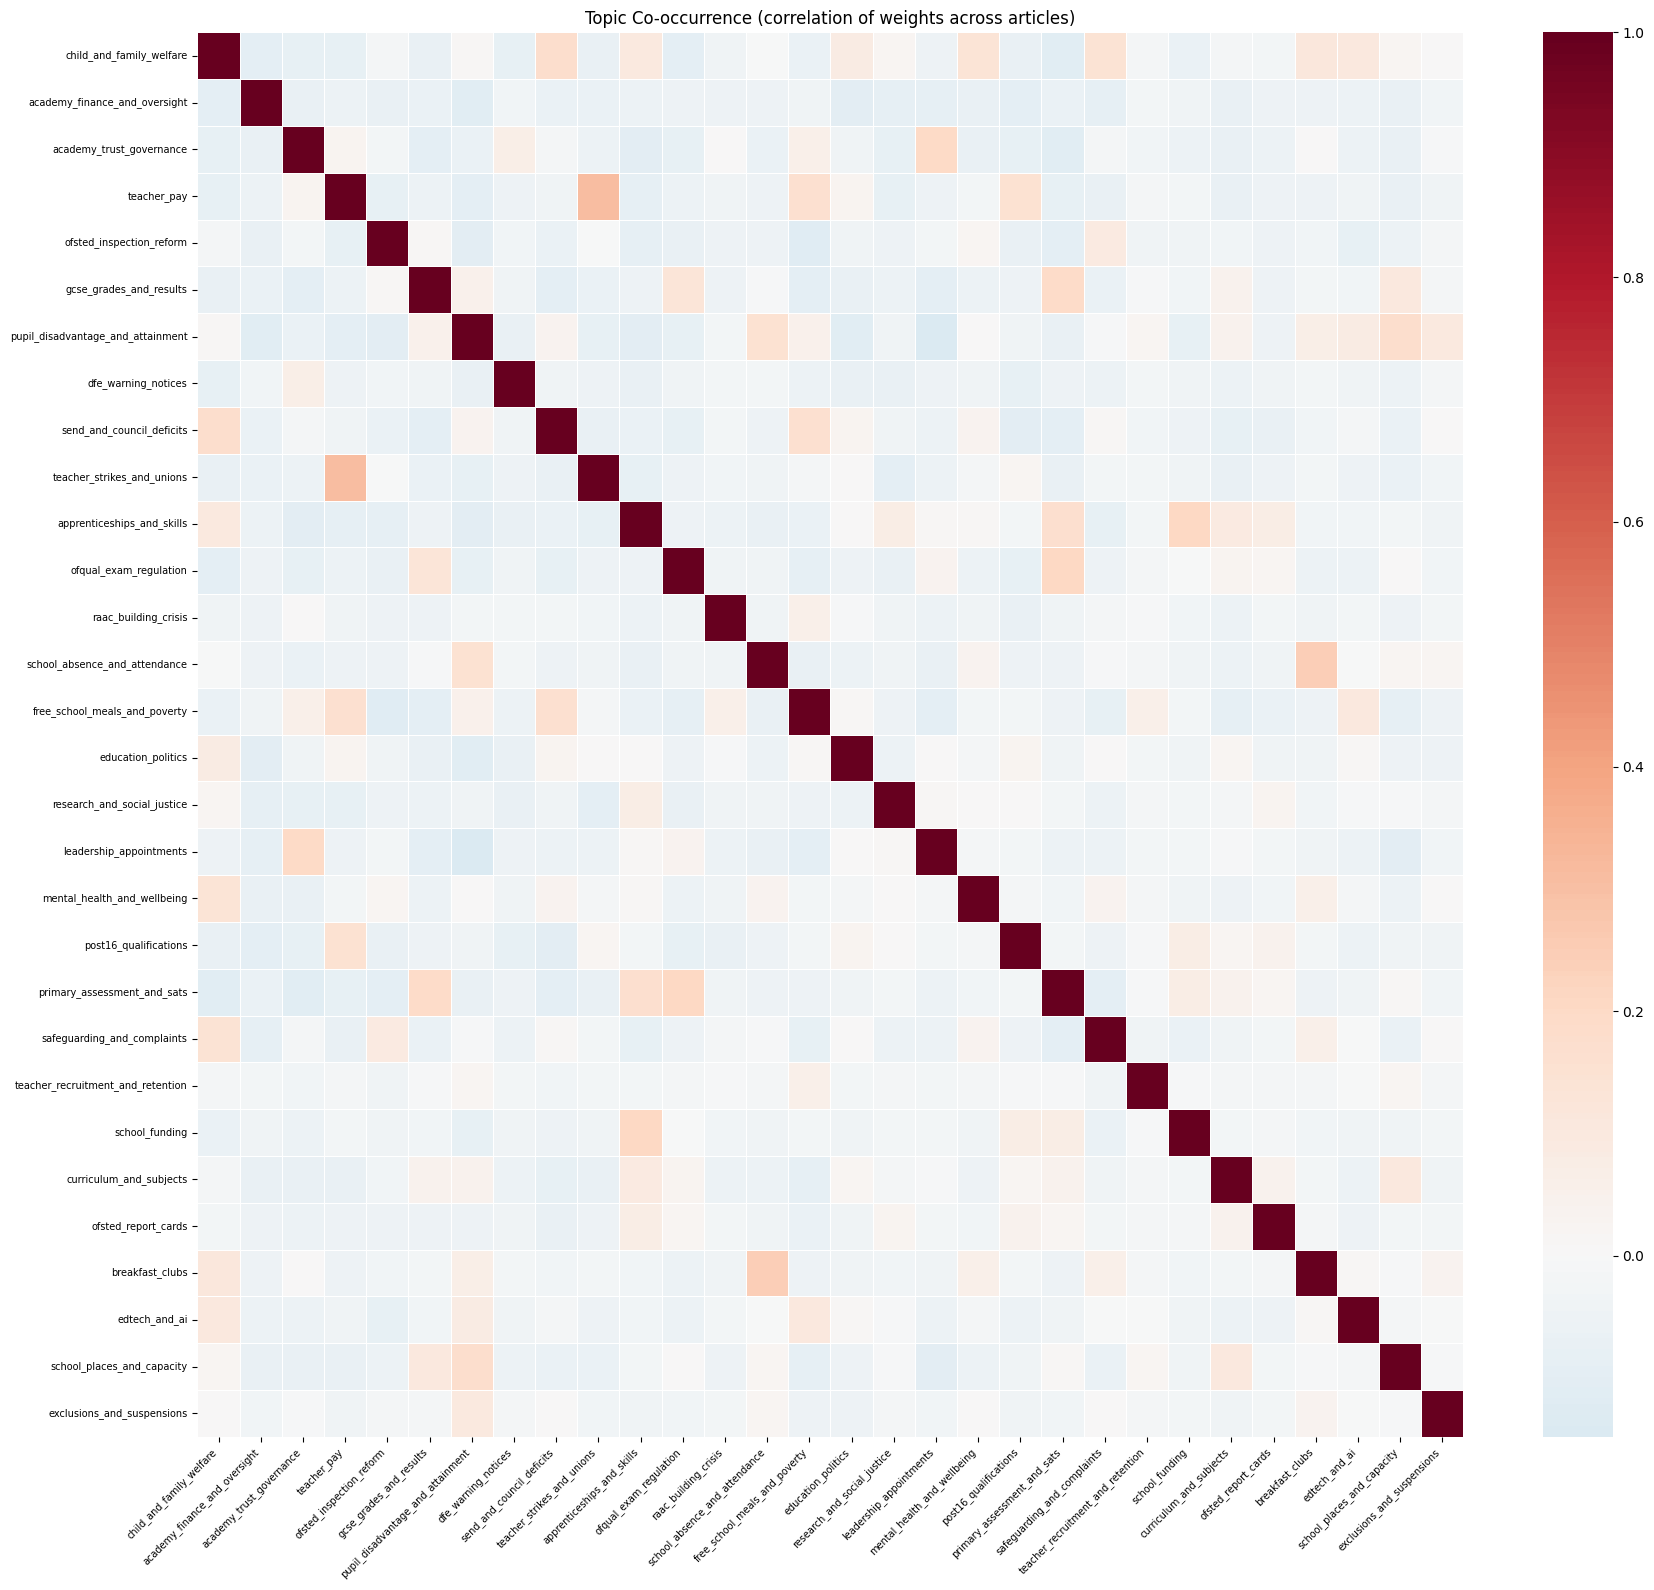


STRONGEST POSITIVE CO-OCCURRENCES (topics that appear together):
                          topic_a                       topic_b  correlation
                      teacher_pay    teacher_strikes_and_unions     0.305032
    school_absence_and_attendance               breakfast_clubs     0.247568
       apprenticeships_and_skills                school_funding     0.204750
           ofqual_exam_regulation   primary_assessment_and_sats     0.202418
         academy_trust_governance       leadership_appointments     0.198501
          gcse_grades_and_results   primary_assessment_and_sats     0.189947
pupil_disadvantage_and_attainment    school_places_and_capacity     0.179081
         child_and_family_welfare     send_and_council_deficits     0.178080
       apprenticeships_and_skills   primary_assessment_and_sats     0.172792
        send_and_council_deficits free_school_meals_and_poverty     0.165473

STRONGEST NEGATIVE CO-OCCURRENCES (topics that never appear together):
               

In [12]:
# Topic weight columns (the 30 per-article weights)
topic_cols = [c for c in df.columns if c not in [
    "url", "article_date", "year", "month", "source", "type", "text_clean",
    "topic_num", "topic_name", "dominant_topic_weight", "period"
]]

print(f"Topic weight columns: {len(topic_cols)}")

# Correlation matrix of topic weights across articles
topic_corr = df[topic_cols].corr()

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(topic_corr, cmap="RdBu_r", center=0, annot=False, 
            xticklabels=True, yticklabels=True, ax=ax, linewidths=0.5)
ax.set_title("Topic Co-occurrence (correlation of weights across articles)")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/topic_cooccurrence_eng_k30.png", dpi=150, bbox_inches="tight")
plt.show()

# Strongest positive co-occurrences (excluding diagonal)
import itertools
pairs = []
for i, j in itertools.combinations(range(len(topic_cols)), 2):
    pairs.append({
        "topic_a": topic_cols[i],
        "topic_b": topic_cols[j],
        "correlation": topic_corr.iloc[i, j],
    })

pairs_df = pd.DataFrame(pairs).sort_values("correlation", ascending=False)
print("\nSTRONGEST POSITIVE CO-OCCURRENCES (topics that appear together):")
print(pairs_df.head(10).to_string(index=False))

print("\nSTRONGEST NEGATIVE CO-OCCURRENCES (topics that never appear together):")
print(pairs_df.tail(10).to_string(index=False))

#### Interpretation
Positive correlations reveal topics that co-occur in the same articles — these are policy areas that journalists and authors treat as connected. For example, teacher_pay and teacher_strikes may correlate because Schools Week covers both in the same piece. Negative correlations reveal topics that never appear together — e.g. ESFA regulatory notices and mental health content are likely strongly negative because they come from completely different types of publication. The co-occurrence structure is a map of how the education system's policy areas are linked in public discourse.

## 10. Temporal spikes — event-driven topic attention

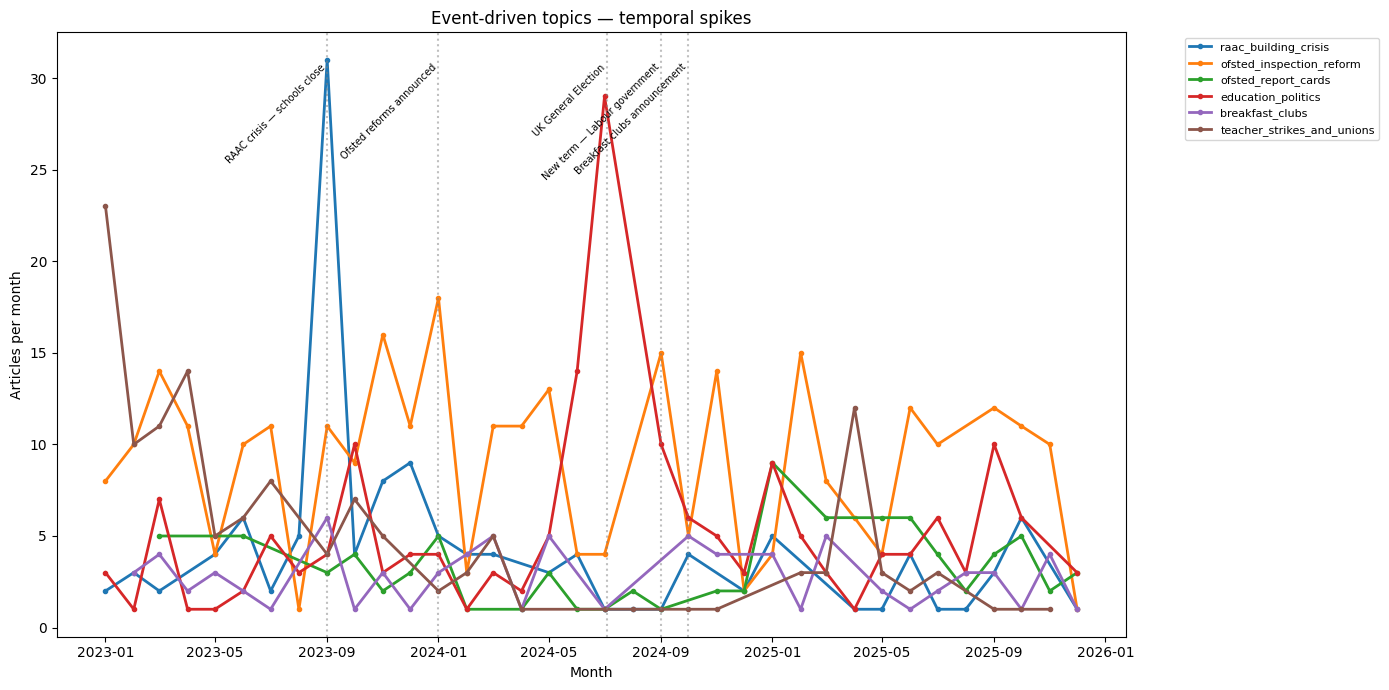


SPIKE DETECTION (months where topic count > 2x monthly mean):
--------------------------------------------------------------------------------
  curriculum_and_subjects: mean=4.3, spikes at 2023-07-01, 2025-03-01, 2025-11-01
  gcse_grades_and_results: mean=3.6, spikes at 2023-08-01, 2024-08-01, 2025-08-01
  primary_assessment_and_sats: mean=4.5, spikes at 2023-01-01, 2023-06-01, 2023-07-01, 2024-08-01, 2024-12-01
  school_absence_and_attendance: mean=1.9, spikes at 2024-03-01
  research_and_social_justice: mean=4.6, spikes at 2023-11-01
  post16_qualifications: mean=6.1, spikes at 2023-06-01, 2024-09-01
  edtech_and_ai: mean=3.4, spikes at 2024-11-01, 2025-02-01, 2025-04-01, 2025-06-01, 2025-11-01
  ofsted_report_cards: mean=3.4, spikes at 2025-01-01
  school_places_and_capacity: mean=4.1, spikes at 2023-05-01, 2023-07-01
  child_and_family_welfare: mean=2.4, spikes at 2024-11-01, 2024-12-01, 2025-10-01
  mental_health_and_wellbeing: mean=2.2, spikes at 2023-05-01, 2024-02-01
  exclus

In [13]:
# Key events in English education 2023-2025
events = {
    "2023-09-01": "RAAC crisis — schools close",
    "2024-01-01": "Ofsted reforms announced",
    "2024-07-04": "UK General Election",
    "2024-09-01": "New term — Labour government",
    "2024-10-01": "Breakfast clubs announcement",
}

# Monthly article counts for specific event-linked topics
event_topics = ["raac_building_crisis", "ofsted_inspection_reform", "ofsted_report_cards",
                "education_politics", "breakfast_clubs", "teacher_strikes_and_unions"]

monthly_events = df[df["topic_name"].isin(event_topics)].groupby(
    ["month", "topic_name"]).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(14, 7))
for topic in event_topics:
    topic_data = monthly_events[monthly_events["topic_name"] == topic]
    if len(topic_data) > 0:
        ax.plot(topic_data["month"], topic_data["count"], label=topic, marker=".", linewidth=2)

# Add event markers
for date_str, label in events.items():
    date = pd.Timestamp(date_str)
    ax.axvline(date, color="gray", linestyle=":", alpha=0.5)
    ax.text(date, ax.get_ylim()[1] * 0.95, label, rotation=45, fontsize=7, ha="right", va="top")

ax.set_xlabel("Month")
ax.set_ylabel("Articles per month")
ax.set_title("Event-driven topics — temporal spikes")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/temporal_spikes_eng_k30.png", dpi=150, bbox_inches="tight")
plt.show()

# Spike detection: months where a topic's count exceeds 2x its mean
print("\nSPIKE DETECTION (months where topic count > 2x monthly mean):")
print("-" * 80)
for topic in df["topic_name"].unique():
    topic_monthly = df[df["topic_name"] == topic].groupby("month").size()
    mean_count = topic_monthly.mean()
    spikes = topic_monthly[topic_monthly > 2 * mean_count]
    if len(spikes) > 0:
        spike_dates = ", ".join(str(d.date()) for d in spikes.index)
        print(f"  {topic}: mean={mean_count:.1f}, spikes at {spike_dates}")

#### Interpretation
Temporal spikes connect the topic model to real-world events. RAAC should spike around September 2023 when schools closed. Education politics should spike around July 2024 (election). Breakfast clubs should appear in late 2024 (Labour policy announcement). Teacher strikes should spike in early 2023 (NEU action). Spike detection (>2x monthly mean) identifies months where a topic's attention was anomalous — these are the moments where the education discourse shifted. Topics that never spike are structural (always present at a steady rate). Topics that only exist as spikes are event-driven (no sustained attention outside the crisis).

## 11. LLM Framing Analysis — AI & EdTech pre/post election

How is AI in education framed before and after the July 2024 election? The same topic may be discussed through different lenses — opportunity, risk, regulation, disruption, equity — and the dominant framing may shift with a change of government. This analysis uses Claude to classify the framing of each article, then compares the distribution pre vs post election.

In [14]:
import os
from dotenv import load_dotenv
from anthropic import Anthropic
import json
import re
import time

load_dotenv(Path("/workspaces/AM1_topic_modelling/.env"))
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

# Get all edtech_and_ai articles, split by period
ai_df = df[df["topic_name"] == "edtech_and_ai"].copy()
ai_pre = ai_df[ai_df["period"] == "pre_election"].nlargest(20, "dominant_topic_weight")
ai_post = ai_df[ai_df["period"] == "post_election"].nlargest(20, "dominant_topic_weight")

print(f"AI/EdTech articles: {len(ai_df)} total")
print(f"  Pre-election:  {len(ai_df[ai_df['period'] == 'pre_election'])} (using top 20 by weight)")
print(f"  Post-election: {len(ai_df[ai_df['period'] == 'post_election'])} (using top 20 by weight)")

AI/EdTech articles: 113 total
  Pre-election:  37 (using top 20 by weight)
  Post-election: 76 (using top 20 by weight)


In [15]:
def classify_framing(articles_df, period_label):
    """Send articles to Claude for framing classification."""
    
    article_texts = []
    for i, (_, row) in enumerate(articles_df.iterrows()):
        text = str(row.get("text_clean", ""))[:800]
        source = row.get("source", "unknown")
        date = str(row.get("article_date", ""))[:10]
        article_texts.append(f"ARTICLE {i+1} ({source}, {date}):\n{text}")
    
    prompt = f"""You are analysing how AI and educational technology is framed in UK education policy articles.

These are {len(article_texts)} articles from the {period_label} period. For each article, classify the PRIMARY framing into exactly one of these categories:

- OPPORTUNITY: AI/tech as beneficial, enabling, innovative, improving outcomes
- RISK: AI/tech as dangerous, threatening, requiring caution, cheating concerns
- REGULATION: focus on governance, standards, safety frameworks, compliance
- DISRUPTION: AI/tech as transformative, changing how education works fundamentally  
- EQUITY: AI/tech in relation to access, inclusion, digital divide, disadvantage
- EVIDENCE: research findings, evaluations, data about AI/tech effectiveness
- COMMERCIAL: products, markets, procurement, edtech industry, Bett conference

Also provide a one-sentence summary of each article's framing.

{chr(10).join(article_texts)}

Return ONLY a JSON list:
[
  {{"article": 1, "framing": "OPPORTUNITY", "summary": "one sentence"}},
  ...
]
No other text, no markdown, no code fences."""

    response = client.messages.create(
        model="claude-sonnet-4-20250514",
        max_tokens=4096,
        messages=[{"role": "user", "content": prompt}],
    )
    
    text = response.content[0].text
    cleaned = re.sub(r'^```(?:json)?\n?', '', text.strip())
    cleaned = re.sub(r'\n?```$', '', cleaned.strip())
    return json.loads(cleaned)

# Classify both periods
print("Classifying pre-election articles...")
pre_results = classify_framing(ai_pre, "pre-election (before July 2024)")

print("Classifying post-election articles...")
post_results = classify_framing(ai_post, "post-election (after July 2024)")

print(f"\nClassified: {len(pre_results)} pre, {len(post_results)} post")

Classifying pre-election articles...
Classifying post-election articles...

Classified: 20 pre, 20 post


FRAMING COMPARISON — AI/EdTech pre vs post election
             pre_election  post_election  pre_pct  post_pct  shift
OPPORTUNITY             0             13      0.0      65.0   65.0
RISK                    0              4      0.0      20.0   20.0
REGULATION              1              0      5.0       0.0   -5.0
DISRUPTION              0              0      0.0       0.0    0.0
EQUITY                 17              0     85.0       0.0  -85.0
EVIDENCE                2              1     10.0       5.0   -5.0
COMMERCIAL              0              2      0.0      10.0   10.0


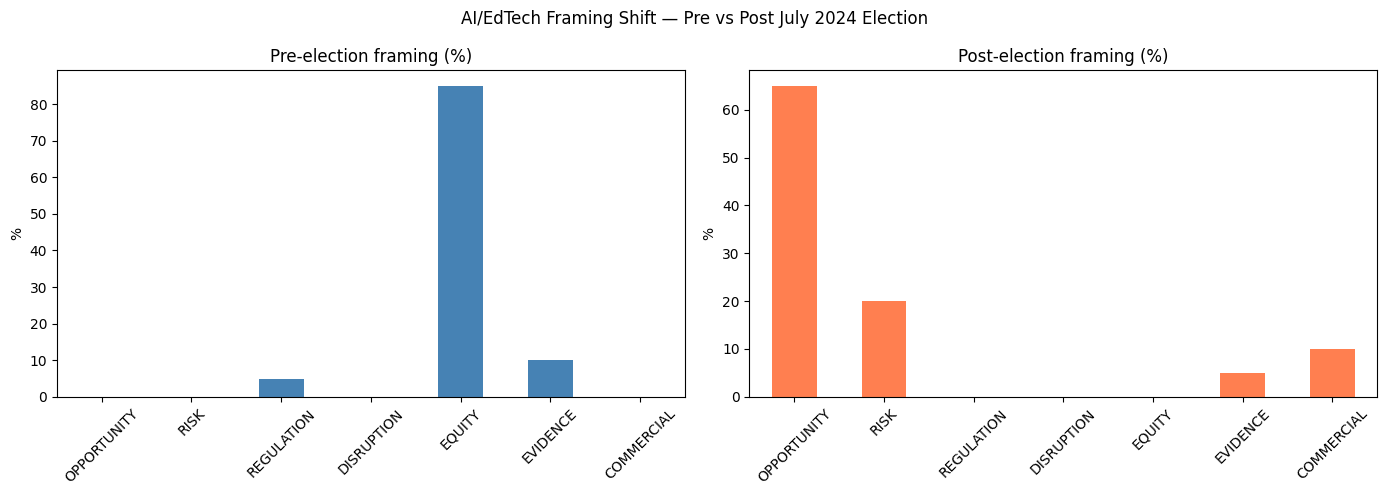



PRE-ELECTION FRAMING DETAIL:
----------------------------------------------------------------------
  [EQUITY      ] The article frames Sadiq Khan's free school meals extension as addressing disadvantage but highlights funding shortfalls that could burden schools.
  [EQUITY      ] The article frames the government funding increase for infant free school meals as inadequate to address the real costs faced by schools due to inflation.
  [EQUITY      ] The article frames Khan's extension of London primary free school meals as addressing access but warns of continued underfunding challenges.
  [EQUITY      ] The article frames school breakfast funding and free school meals expansion as necessary to address growing hunger among disadvantaged pupils.
  [EQUITY      ] The article frames the Liberal Democrats' free school meals policy as an unfunded aspiration to address poverty rather than a concrete commitment.
  [EQUITY      ] The article frames Newham's universal free school meals progra

In [16]:
# Compare framing distributions
pre_framings = pd.Series([r["framing"] for r in pre_results]).value_counts()
post_framings = pd.Series([r["framing"] for r in post_results]).value_counts()

framing_categories = ["OPPORTUNITY", "RISK", "REGULATION", "DISRUPTION", "EQUITY", "EVIDENCE", "COMMERCIAL"]
comparison = pd.DataFrame({
    "pre_election": pre_framings.reindex(framing_categories, fill_value=0),
    "post_election": post_framings.reindex(framing_categories, fill_value=0),
})
comparison["pre_pct"] = (comparison["pre_election"] / comparison["pre_election"].sum() * 100).round(1)
comparison["post_pct"] = (comparison["post_election"] / comparison["post_election"].sum() * 100).round(1)
comparison["shift"] = comparison["post_pct"] - comparison["pre_pct"]

print("FRAMING COMPARISON — AI/EdTech pre vs post election")
print("=" * 70)
print(comparison.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison["pre_pct"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Pre-election framing (%)")
axes[0].set_ylabel("%")
axes[0].tick_params(axis='x', rotation=45)

comparison["post_pct"].plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Post-election framing (%)")
axes[1].set_ylabel("%")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("AI/EdTech Framing Shift — Pre vs Post July 2024 Election", fontsize=12)
plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/framing_ai_edtech_eng_k30.png", dpi=150, bbox_inches="tight")
plt.show()

# Show article-level detail
print("\n\nPRE-ELECTION FRAMING DETAIL:")
print("-" * 70)
for r in pre_results:
    print(f"  [{r['framing']:<12}] {r['summary']}")

print("\n\nPOST-ELECTION FRAMING DETAIL:")
print("-" * 70)
for r in post_results:
    print(f"  [{r['framing']:<12}] {r['summary']}")

In [17]:
# Source × framing breakdown
pre_source_framing = pd.DataFrame([
    {"source": ai_pre.iloc[i]["source"], "framing": r["framing"]}
    for i, r in enumerate(pre_results) if i < len(ai_pre)
])
post_source_framing = pd.DataFrame([
    {"source": ai_post.iloc[i]["source"], "framing": r["framing"]}
    for i, r in enumerate(post_results) if i < len(ai_post)
])

print("SOURCE × FRAMING — Pre-election:")
if len(pre_source_framing) > 0:
    print(pd.crosstab(pre_source_framing["source"], pre_source_framing["framing"]).to_string())

print("\nSOURCE × FRAMING — Post-election:")
if len(post_source_framing) > 0:
    print(pd.crosstab(post_source_framing["source"], post_source_framing["framing"]).to_string())

# Save results
framing_output = {
    "topic": "edtech_and_ai",
    "election_date": "2024-07-04",
    "pre_election": pre_results,
    "post_election": post_results,
    "comparison": comparison.to_dict(),
}
with open("/workspaces/AM1_topic_modelling/data/evaluation_outputs/framing_ai_edtech.json", "w") as f:
    json.dump(framing_output, f, indent=2)
print("\nSaved to data/evaluation_outputs/framing_ai_edtech.json")

SOURCE × FRAMING — Pre-election:
framing      EQUITY  EVIDENCE  REGULATION
source                                   
fft               0         1           0
schoolsweek      17         1           1

SOURCE × FRAMING — Post-election:
framing      COMMERCIAL  EVIDENCE  OPPORTUNITY  RISK
source                                              
gov                   0         0            9     0
schoolsweek           2         1            4     4

Saved to data/evaluation_outputs/framing_ai_edtech.json


#### Interpretation

The framing shift reveals how the same policy area — AI in education — is discussed differently under different governments. The framing categories themselves are a specification choice: these seven categories were chosen by the researcher and classified by an LLM. A different set of categories or a different LLM would produce different distributions. The source × framing crosstab shows whether different actors frame AI differently — does government emphasise regulation while media emphasises opportunity? Does this change after the election?

**Contestability point:** The LLM framing classification is itself a specification layer on top of the topic model. The topic model found "edtech_and_ai" as a cluster. The framing analysis subdivides that cluster using an LLM prompt. The framing categories, the prompt wording, the model choice (Sonnet), and the article selection (top 20 by weight) are all specification choices that shape the output. This is specification sensitivity all the way down.

# ***Findings and Contestability Conclusions***

What the England k=30 analysis reveals about contestability
1. Temporal context is a hidden specification choice. The July 2024 election shifted topic rankings — topics rose and fell with the political cycle. A model trained on pre-election data describes a different policy landscape than one trained on post-election data. "When was this model trained?" is a specification choice no deployed system discloses.

2. Single-topic labels destroy information. Mean dominant weight of 0.12 means 88% of each article's content is hidden behind one label. The co-occurrence structure — which topics appear together — reveals policy connections that dominant-topic assignment erases. SEND + funding + workforce appearing together tells policymakers these issues are linked. One label tells them nothing.

3. Event-driven vs structural topics are treated identically. RAAC spiked and faded. Academy governance is always there. The model and dashboard treat both as equivalent "topics" — but one is a crisis response and the other is permanent infrastructure. A contestable system would distinguish between these.

4. Framing analysis is specification sensitivity all the way down. The topic model is one layer of specification choices. The LLM framing classification adds a second layer — framing categories, prompt wording, model choice, article selection. Each layer compounds the specification sensitivity. A user seeing "OPPORTUNITY 40%" doesn't know how many choices produced that number.

5. Framing is institutional, not topical. Different sources frame the same topic differently — government emphasises regulation, media emphasises opportunity. Source concentration determines not just which topics appear but how they're framed. Two dimensions of specification sensitivity: whose voice is in the corpus, and whose framing dominates.